In [ ]:
!pip install kagglehub --quiet

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [ ]:
path = kagglehub.dataset_download("uom190346a/sleep-health-and-lifestyle-dataset")
print("Dataset downloaded to:", path)

os.listdir(path)


Using Colab cache for faster access to the 'sleep-health-and-lifestyle-dataset' dataset.
Dataset downloaded to: /kaggle/input/sleep-health-and-lifestyle-dataset


['Sleep_health_and_lifestyle_dataset.csv']

In [ ]:
df = pd.read_csv(os.path.join(path, "Sleep_health_and_lifestyle_dataset.csv"))
df.head()


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [ ]:
df.shape


(374, 13)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [ ]:
df.describe()


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [ ]:
df.isna().sum()


,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
df.columns.tolist()


['Person ID',
 'Gender',
 'Age',
 'Occupation',
 'Sleep Duration',
 'Quality of Sleep',
 'Physical Activity Level',
 'Stress Level',
 'BMI Category',
 'Blood Pressure',
 'Heart Rate',
 'Daily Steps',
 'Sleep Disorder']

In [ ]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_')
      .str.replace('-', '_')
)

df.columns.tolist()


['person_id',
 'gender',
 'age',
 'occupation',
 'sleep_duration',
 'quality_of_sleep',
 'physical_activity_level',
 'stress_level',
 'bmi_category',
 'blood_pressure',
 'heart_rate',
 'daily_steps',
 'sleep_disorder']

In [ ]:
numeric_cols = [
    'age',
    'sleep_duration',
    'quality_of_sleep',
    'physical_activity_level',
    'stress_level',
    'heart_rate',
    'daily_steps'
]

for col in numeric_cols:
    print(col, "min:", df[col].min(), "| max:", df[col].max())


age min: 27 | max: 59
sleep_duration min: 5.8 | max: 8.5
quality_of_sleep min: 4 | max: 9
physical_activity_level min: 30 | max: 90
stress_level min: 3 | max: 8
heart_rate min: 65 | max: 86
daily_steps min: 3000 | max: 10000


In [ ]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_')
      .str.replace('-', '_')
)


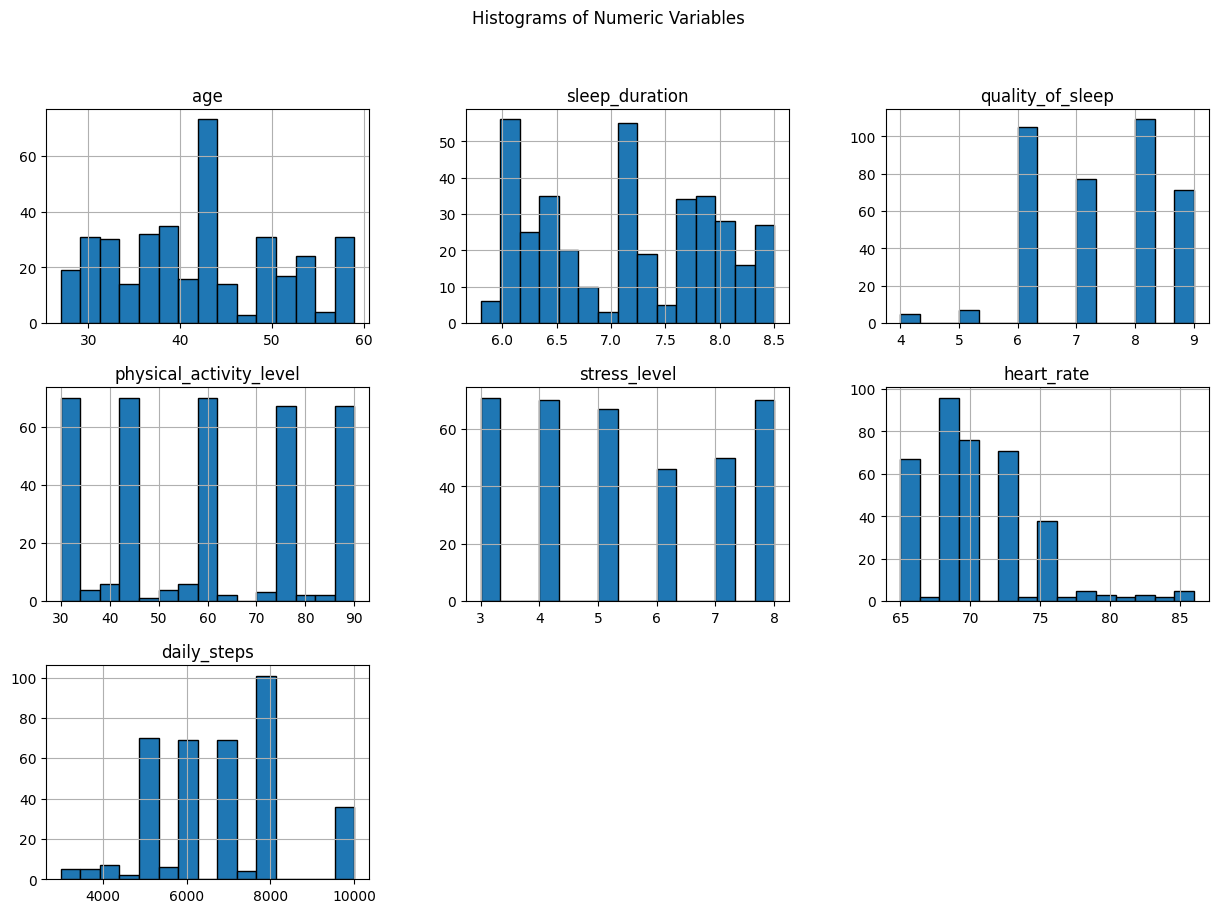

In [ ]:
numeric_cols = [
    'age',
    'sleep_duration',
    'quality_of_sleep',
    'physical_activity_level',
    'stress_level',
    'heart_rate',
    'daily_steps'
]

df[numeric_cols].hist(figsize=(15,10), bins=15, edgecolor='black')
plt.suptitle("Histograms of Numeric Variables")
plt.show()


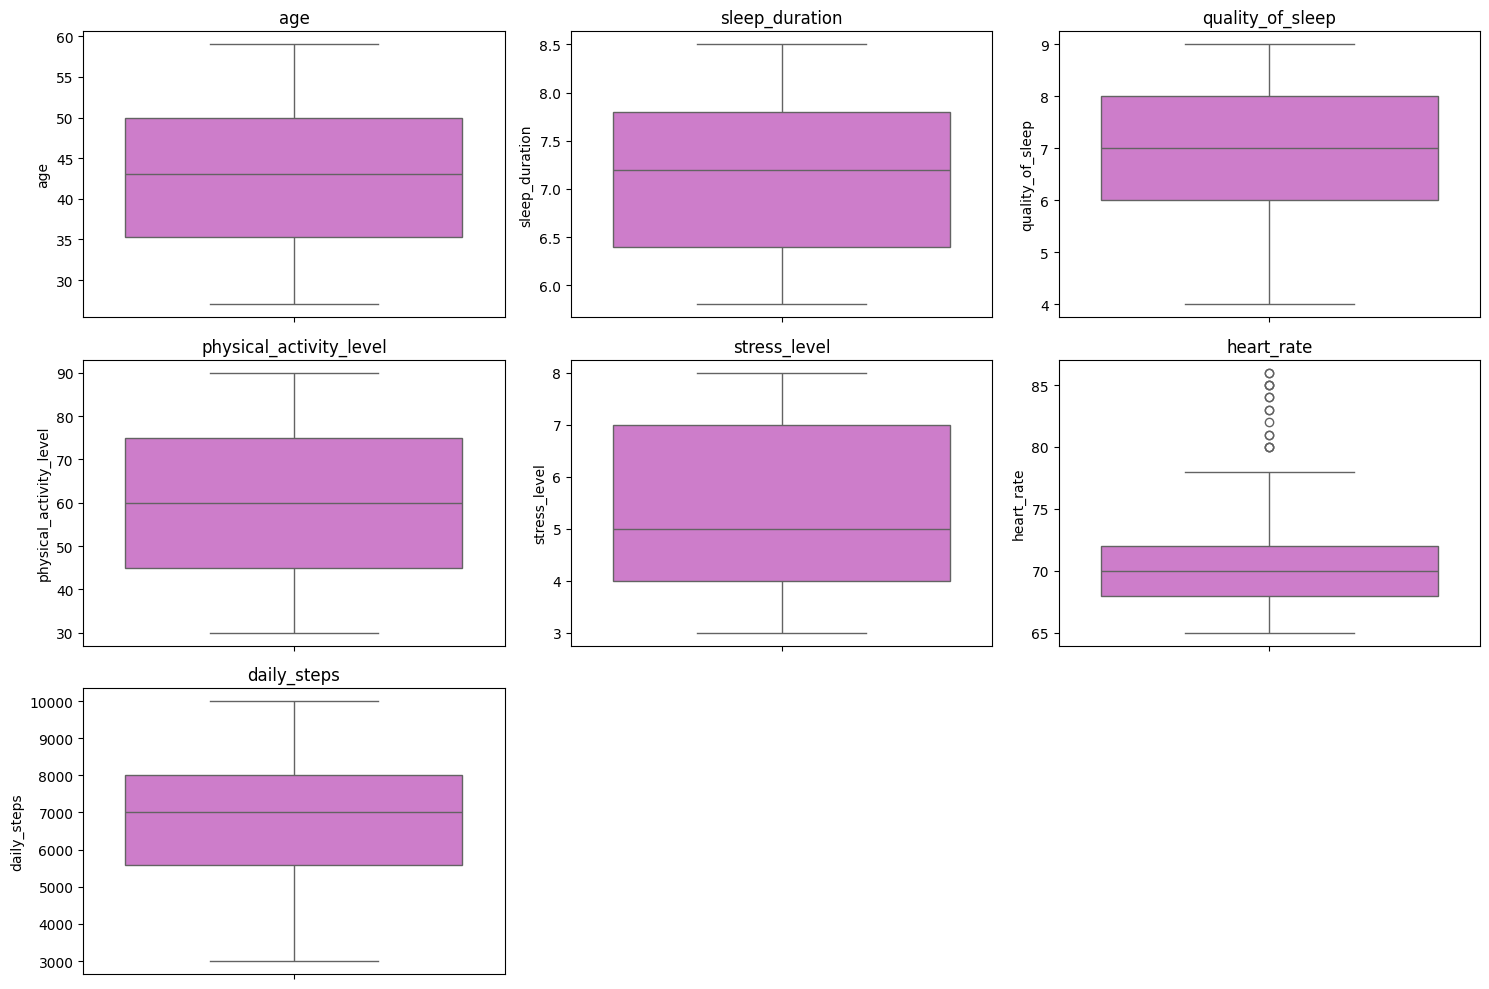

In [ ]:
plt.figure(figsize=(15,10))

for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=df[col], color='orchid')
    plt.title(col)

plt.tight_layout()
plt.show()


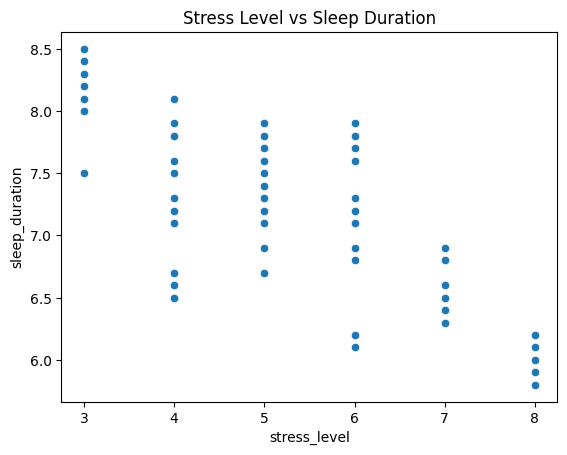

In [ ]:
sns.scatterplot(data=df, x='stress_level', y='sleep_duration')
plt.title("Stress Level vs Sleep Duration")
plt.show()


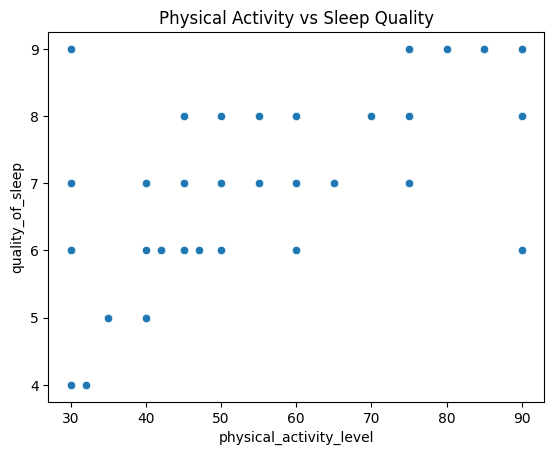

In [ ]:
sns.scatterplot(data=df, x='physical_activity_level', y='quality_of_sleep')
plt.title("Physical Activity vs Sleep Quality")
plt.show()


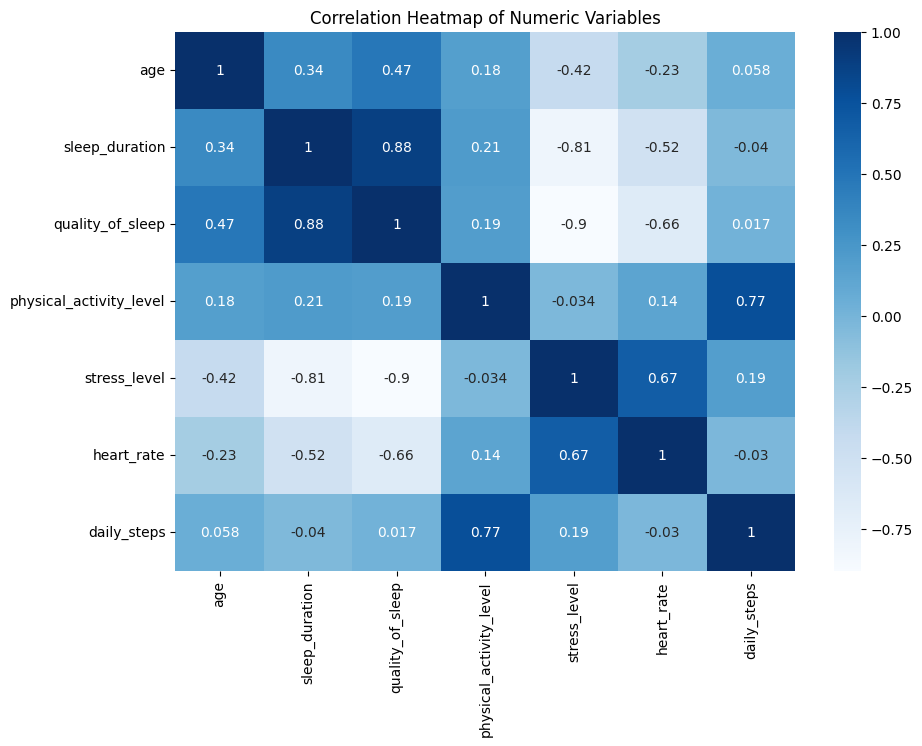

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='Blues')
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()


In [ ]:
df['sleep_disorder'].value_counts()


,count
sleep_disorder,
Sleep Apnea,78
Insomnia,77


In [ ]:
df['sleep_disorder'].value_counts(dropna=False)



,count
sleep_disorder,
NaN,219
Sleep Apnea,78
Insomnia,77


In [ ]:
df['sleep_disorder'] = df['sleep_disorder'].fillna("None")


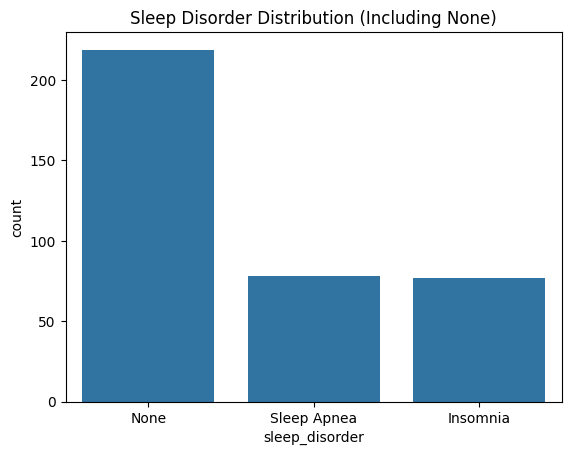

In [ ]:
sns.countplot(data=df, x='sleep_disorder')
plt.title("Sleep Disorder Distribution (Including None)")
plt.show()


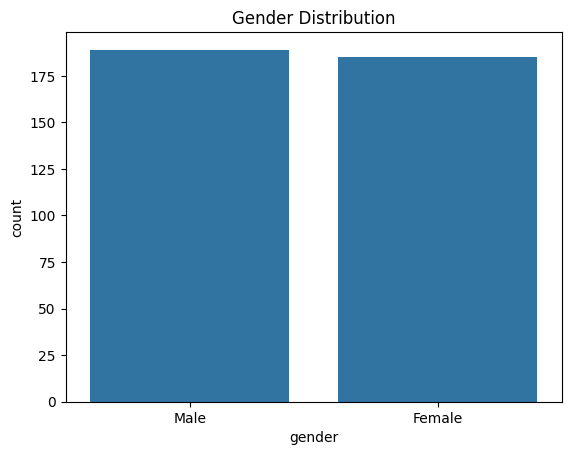

In [ ]:
sns.countplot(data=df, x='gender')
plt.title("Gender Distribution")
plt.show()


In [ ]:
# Supervised Model: Logistic Regression

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Sleep_health_and_lifestyle_dataset.csv to Sleep_health_and_lifestyle_dataset (1).csv


In [ ]:
df['good_sleep'] = (df['Quality of Sleep'] >= 7).astype(int)


In [ ]:
numeric_features = ['Age', 'Sleep Duration', 'Physical Activity Level',
                    'Daily Steps', 'Stress Level', 'Heart Rate']
categorical_features = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']

X = df[numeric_features + categorical_features].copy()
y = df['good_sleep']

In [ ]:
data = pd.concat([X, y], axis=1).dropna()
X = data[numeric_features + categorical_features]
y = data['good_sleep']

In [ ]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [ ]:
log_reg = LogisticRegression(max_iter=1000)

clf = Pipeline(steps=[('preprocess', preprocess),
                     ('model', log_reg)])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.967741935483871
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       1.00      0.94      0.97        16

    accuracy                           0.97        31
   macro avg       0.97      0.97      0.97        31
weighted avg       0.97      0.97      0.97        31



/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


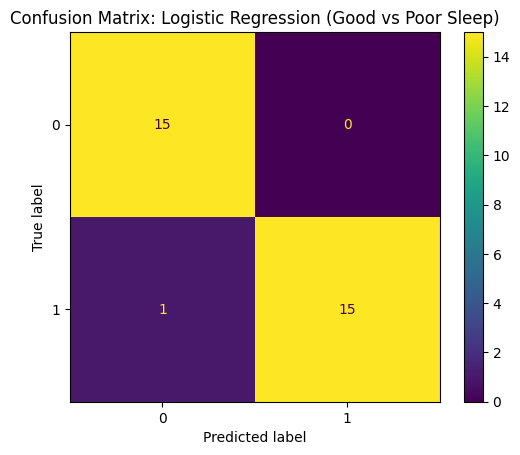

In [ ]:

ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
plt.title("Confusion Matrix: Logistic Regression (Good vs Poor Sleep)")
plt.show()

In [ ]:
import numpy as np

log_reg = clf.named_steps['model']

ohe = clf.named_steps['preprocess'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(cat_feature_names)

# coefficients
coefs = log_reg.coef_[0]

for name, c in sorted(zip(all_feature_names, coefs), key=lambda x: abs(x[1]), reverse=True):
    print(f"{name:30s} {c: .3f}")


Stress Level                   -1.786
Sleep Duration                  1.431
Occupation_Salesperson         -1.399
Age                             1.193
Heart Rate                     -0.926
Gender_Male                    -0.903
BMI Category_Overweight        -0.671
Daily Steps                    -0.654
Occupation_Lawyer               0.572
Occupation_Nurse               -0.541
BMI Category_Obese              0.448
Sleep Disorder_Sleep Apnea     -0.403
BMI Category_Normal Weight     -0.135
Occupation_Engineer             0.114
Occupation_Teacher             -0.111
Occupation_Doctor               0.085
Physical Activity Level        -0.007
Occupation_Scientist           -0.006
Occupation_Sales Representative -0.002
